# MVV Cascade Models w/ Sanity Check Plots
Goal:
- compare bulk, one-compartment, two-compartment, and three-compartment models
- plot model vs experimental data side by side
- verify that intermediate species behave consistently w/ expected cascade

In [ ]:
from biocrnpyler import *
from biocrnpyler.components import Component

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import List, Union

# make plots easier to paste into the report
plt.rcParams["figure.dpi"] = 160

directory = os.getcwd()

# parameter and data files used
PARAMETER_FILE = "MVV_default_parameters.txt"
DATA_FILE = "MVV_all_data.xlsx"

timepoints = np.linspace(0, 600, 600)

COLOR_MODEL = "#d946ef"      
COLOR_DATA = "black"

COLOR_INTERNAL = "#ff7f0e"   

COLOR_H2O2 = "#2ca02c"       
COLOR_RESORUFIN = "#9467bd"  
COLOR_GLUCOSE = "#17becf"   

# aliases used by plotting helper functions
MODEL_COLOR = COLOR_MODEL
DATA_COLOR = COLOR_DATA

FIG_DIR = "cleaned_notebook_figures"
os.makedirs(FIG_DIR, exist_ok=True)


def save_fig(fig, filename):
    path = os.path.join(FIG_DIR, filename)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")


def find_col(df, text, exact=None):
    """
    Helper: find a column by exact name first, then by contained text.
    This keeps plotting code easier to read.
    """
    if exact is not None and exact in df.columns:
        return exact

    matches = [col for col in df.columns if text.lower() in col.lower()]

    if len(matches) == 0:
        raise ValueError(f"No column found containing: {text}")

    if len(matches) > 1:
        print(f"Multiple matches for '{text}': {matches}")
        print(f"Using: {matches[0]}")

    return matches[0]

In [8]:
def find_col(df, text, exact=None):
    """
    Helper: Searching for a column by exact name. If not found, search for a column containing the text.
    This keeps plotting code easier to read.
    """
    if exact is not None and exact in df.columns:
        return exact

    matches = [c for c in df.columns if text.lower() in c.lower()]

    if len(matches) == 0:
        raise ValueError(f"No column found containing: {text}")

    if len(matches) > 1:
        print(f"Multiple matches for '{text}': {matches}")
        print(f"Using: {matches[0]}")

    return matches[0]


def save_fig(fig, filename):
    """
    Save figure to a folder. 
    Keeps the code cleaner and manages the file paths in one place. Also prints the path so it's easier to find.
    """
    path = os.path.join(FIG_DIR, filename)
    fig.savefig(path, bbox_inches="tight")
    print(f"Saved: {path}")


def plot_single_model(time, y, title, ylabel="Fluor (a.u.)", filename=None, ymax=None):
    """
    Plot one model output by itself. Used for sanity checks and to show the model without data for comparison.
    """
    fig, ax = plt.subplots(figsize=(5, 3.5))

    ax.plot(time, y, color=MODEL_COLOR, linewidth=2, label="Model")
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, 600)

    if ymax is not None:
        ax.set_ylim(0, ymax)

    ax.legend()
    fig.tight_layout()

    if filename is not None:
        save_fig(fig, filename)

    plt.show()


def plot_model_vs_data_side_by_side(
    model_time,
    model_y,
    data_time,
    data_y,
    model_title,
    data_title,
    filename=None,
    model_ylabel="Model fluor (a.u.)",
    data_ylabel="Data fluor (a.u.)",
    model_ymax=None,
    data_ymax=None
):
    """
    Side-by-side model/data plot for the report.
    Model stays magenta and data stays black dashed.
    """
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

    # model plot
    axes[0].plot(model_time, model_y, color=MODEL_COLOR, linewidth=2, label="Model")
    axes[0].set_title(model_title)
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel(model_ylabel)
    axes[0].set_xlim(0, 600)
    if model_ymax is not None:
        axes[0].set_ylim(0, model_ymax)
    axes[0].legend()

    # data plot
    axes[1].plot(data_time, data_y, color=DATA_COLOR, linestyle="--", linewidth=2, label="Data")
    axes[1].set_title(data_title)
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel(data_ylabel)
    axes[1].set_xlim(0, 600)
    if data_ymax is not None:
        axes[1].set_ylim(0, data_ymax)
    axes[1].legend()

    fig.tight_layout()

    if filename is not None:
        save_fig(fig, filename)

    plt.show()

In [ ]:
# note:
# enzyme components to represent enzymes and their substrates/products in specific compartments
# This lets an enzyme, its substrates, and its products be placed in a specific compartment.

class EnzymeCompartment(Component):
    """
    Helper class to represent enzymes with multiple substrates and products.

    This is used so that enzyme reactions can happen inside a named compartment.
    For example:
        stachyose -> glucose inside the aGlc compartment
        glucose + O2 -> H2O2 inside the GOx compartment
        H2O2 + AUR -> resorufin inside the HRP/main compartment
    """

    def __init__(
        self,
        enzyme: Union[Species, str, Component],
        substrates: Union[List[Union[Species, str, Component]], Species, str, Component],
        products: Union[List[Union[Species, str, Component]], Species, str, Component],
        compartment=None,
        attributes=None,
        **keywords
    ):
        if compartment is None:
            compartment = "default"

        self.enzyme = self.set_species(
            enzyme,
            material_type="protein",
            compartment=compartment,
            attributes=attributes
        )

        self.substrates = substrates
        self.products = products

        Component.__init__(self, name=self.enzyme.name, **keywords)

    @property
    def substrates(self):
        return self._substrates

    @substrates.setter
    def substrates(self, new_substrates):
        compartment = self.enzyme.compartment.name

        if not isinstance(new_substrates, list):
            new_substrates = [new_substrates]

        self._substrates = [
            self.set_species(s, compartment=compartment)
            for s in new_substrates
        ]

    @property
    def products(self):
        return self._products

    @products.setter
    def products(self, new_products):
        compartment = self.enzyme.compartment.name

        if not isinstance(new_products, list):
            new_products = [new_products]

        self._products = [
            self.set_species(p, compartment=compartment)
            for p in new_products
        ]

    def update_species(self):
        mech_cat = self.get_mechanism("catalysis")

        return mech_cat.update_species(
            enzyme=self.enzyme,
            substrate=self.substrates,
            product=self.products
        )

    def update_reactions(self):
        mech_cat = self.get_mechanism("catalysis")

        return mech_cat.update_reactions(
            enzyme=self.enzyme,
            substrate=self.substrates,
            product=self.products,
            component=self,
            part_id=self.name
        )
# compatibility alias so older cells still run
EnzymewCompartment = EnzymeCompartment

In [ ]:
# note:
# load and view the one-compartment experimental data from MVV_all_data.xlsx.
# This is used for the first model vs data comparison.

xlsx_path = os.path.join(directory, DATA_FILE)

df_comp1 = pd.read_excel(xlsx_path, sheet_name="Compartment_1").copy()
df_comp1.columns = df_comp1.columns.str.strip()

print("Compartment_1 columns:")
print(df_comp1.columns.tolist())

df_comp1.head()

Compartment_1 columns:
['Time', '-Gox-aGlc', '-stachyose', '+stachyose']


,Time,-Gox-aGlc,-stachyose,+stachyose
0,0.0,0.000000,0.000000,0.000000
1,7.7,1.728001,0.219227,2.395826
2,15.4,2.998792,0.642662,4.149835
3,23.1,2.655242,0.654432,5.680466
4,30.8,3.927217,0.864212,8.819765


## Bulk Model (No Compartments)

In [ ]:
# note:
# Bulk model = no compartment barriers.
# This is mainly a baseline showing that the reaction network can generate resorufin.

# Reaction 1
aGlc_bulk = Enzyme(
    "aGlc",
    substrates="stachyose",
    products=["glucose", "byproduct"]
)

# Reaction 2
GOx_bulk = Enzyme(
    "GOx",
    substrates=[aGlc_bulk.products[0], "O2"],
    products=["H2O2", "gluconolactone"]
)

# Reaction 3
HRP_bulk = Enzyme(
    "HRP",
    substrates=[GOx_bulk.products[0], "AUR"],
    products=[GOx_bulk.substrates[1], "resorufin"]
)

# Mechanism
mech_cat = MichaelisMenten()
default_mechanisms = {
    mech_cat.mechanism_type: mech_cat
}

M_bulk = Mixture(
    "Catalysis Mixture",
    components=[aGlc_bulk, GOx_bulk, HRP_bulk],
    parameter_file=PARAMETER_FILE,
    mechanisms=default_mechanisms
)

CRN_bulk = M_bulk.compile_crn()

# Reactions
k_leak = 0.00054

H2O2_leak_bulk = Reaction.from_massaction(
    [GOx_bulk.substrates[1], aGlc_bulk.substrates[0]],
    [GOx_bulk.products[0]],
    k_forward=k_leak
)

CRN_bulk.add_reactions([H2O2_leak_bulk])

Results_bulk = CRN_bulk.simulate_with_bioscrape_via_sbml(timepoints)

# note: view bulk results and check that resorufin is being produced.
print("Bulk result columns:")
print(Results_bulk.columns.tolist())

Results_bulk.head()

Bulk result columns:
['protein_aGlc', 'stachyose', 'glucose', 'byproduct', 'complex_protein_aGlc_stachyose_', 'protein_GOx', 'O2', 'H2O2', 'gluconolactone', 'complex_O2_glucose_protein_GOx_', 'protein_HRP', 'AUR', 'resorufin', 'complex_AUR_H2O2_protein_HRP_', 'time']


,protein_aGlc,stachyose,glucose,byproduct,complex_protein_aGlc_stachyose_,protein_GOx,O2,H2O2,gluconolactone,complex_O2_glucose_protein_GOx_,protein_HRP,AUR,resorufin,complex_AUR_H2O2_protein_HRP_,time
0,0.009200,50.000000,0.000000,0.000000,0.000000,0.005100,0.100000,0.000000,0.000000,0.000000,10.000000,10.000000,0.000000,0.000000,0.000000
1,0.000427,48.450771,1.501201,1.537796,0.008773,0.005020,0.099804,0.000006,0.036516,0.000080,9.999890,9.960831,0.039059,0.000110,1.001669
2,0.000441,46.912477,2.931113,3.073532,0.008759,0.004946,0.099626,0.000012,0.142265,0.000154,9.999793,9.852516,0.147277,0.000207,2.003339
3,0.000455,45.376680,4.294789,4.606859,0.008745,0.004878,0.099462,0.000018,0.311848,0.000222,9.999702,9.680455,0.319248,0.000298,3.005008
4,0.000470,43.843534,5.596852,6.137622,0.008730,0.004815,0.099310,0.000024,0.540485,0.000285,9.999619,9.449425,0.550194,0.000381,4.006678


Saved: cleaned_notebook_figures/fig_1A_bulk_model.png


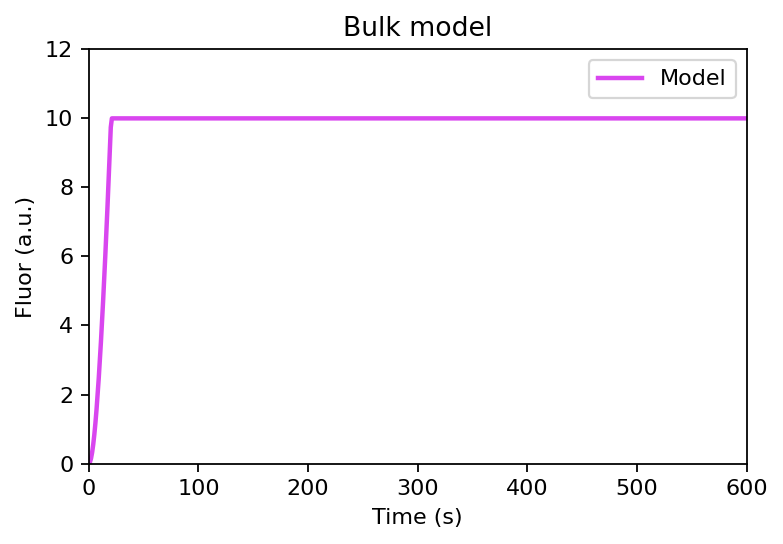

In [10]:
# note: plot the bulk model results
bulk_time_col = find_col(Results_bulk, "time")
bulk_res_col = find_col(Results_bulk, "resorufin")

plot_single_model(
    Results_bulk[bulk_time_col],
    Results_bulk[bulk_res_col],
    title="Bulk model",
    ylabel="Fluor (a.u.)",
    filename="fig_1A_bulk_model.png",
    ymax=12
)

**Bulk model interpretation.**  
The bulk model rises fast and rigidly, and reaches a plateau because all species are in the same reaction space. Since there are no compartment barriers, substrates and enzymes interact immediately. This confirms that the reaction network can produce resorufin when transport is not limiting.

## One-Compartment Model

In [ ]:
# note:
# One-compartment model adds one membrane-separated reaction space.
# This checks whether adding membrane behavior still allows stachyose transport and final resorufin production.

# Vesicle 1 membrane channel / pore
ahl_monomer = IntegralMembraneProtein(
    "ahl_monomer",
    product="aHL"
)

ahl_stachyose = MembraneChannel(
    ahl_monomer.product,
    substrate="stachyose"
)

# aGlc catalysis of stachyose
aGlc_comp1 = EnzymewCompartment(
    "aGlc",
    substrates=ahl_stachyose.substrate,
    products=["byproduct", "glucose"],
    compartment=ahl_stachyose.substrate.compartment.name
)

# GOx catalysis of glucose
GOx_comp1 = EnzymewCompartment(
    "GOx",
    substrates=[aGlc_comp1.products[1], "O2"],
    products=["H2O2", "gluconolactone"],
    compartment=ahl_stachyose.substrate.compartment.name
)

# HRP catalysis of AUR and H2O2
HRP_comp1 = EnzymewCompartment(
    "HRP",
    substrates=[GOx_comp1.products[0], "AUR"],
    products=[GOx_comp1.substrates[1], "resorufin"],
    compartment=ahl_stachyose.substrate.compartment.name
)

# Mechanisms
mech_cat = MichaelisMenten()
mech_transport = Simple_Transport()
mech_diffusion = Simple_Diffusion()

all_mechanisms_comp1 = {
    mech_cat.mechanism_type: mech_cat,
    mech_transport.mechanism_type: mech_transport,
    mech_diffusion.mechanism_type: mech_diffusion
}

M_comp1 = Mixture(
    "Catalysis Mixture",
    components=[ahl_stachyose, aGlc_comp1, GOx_comp1, HRP_comp1],
    parameter_file=PARAMETER_FILE,
    mechanisms=all_mechanisms_comp1
)

CRN_comp1 = M_comp1.compile_crn()

# Additional reactions to show H2O2 leak from GOx -> needed for resorufin production in the model, since H2O2 is produced in the same compartment as aGlc and can react with stachyose.
k_leak = 0.00054

H2O2_leak_comp1 = Reaction.from_massaction(
    [GOx_comp1.substrates[1], aGlc_comp1.substrates[0]],
    [GOx_comp1.products[0]],
    k_forward=k_leak
)

CRN_comp1.add_reactions([H2O2_leak_comp1])

# Init conditions for the one-compartment model.
initial_conc_comp1 = {
    "stachyose_External": 50000,
    "stachyose_Internal": 0,
    "protein_aHL_Passive_Membrane": 1,
    "protein_aGlc_Internal": 9.2e-3,
    "protein_GOx_Internal": 5.1e-3,
    "O2_Internal": 0.1,
    "protein_HRP_Internal": 10,
    "AUR_Internal": 10
}

Results_comp1 = CRN_comp1.simulate_with_bioscrape_via_sbml(
    timepoints,
    initial_condition_dict=initial_conc_comp1
)

# note: check one-compartment model results and check that resorufin is being produced.
print("One-compartment result columns:")
print(Results_comp1.columns.tolist())

Results_comp1.head()

One-compartment result columns:
['protein_aHL_Passive_Membrane', 'stachyose_Internal', 'stachyose_External', 'protein_aGlc_Internal', 'byproduct_Internal', 'glucose_Internal', 'complex_protein_aGlc_Internal_stachyose_Internal_', 'protein_GOx_Internal', 'O2_Internal', 'H2O2_Internal', 'gluconolactone_Internal', 'complex_O2_Internal_glucose_Internal_protein_GOx_Internal_', 'protein_HRP_Internal', 'AUR_Internal', 'resorufin_Internal', 'complex_AUR_Internal_H2O2_Internal_protein_HRP_Internal_', 'time']


,protein_aHL_Passive_Membrane,stachyose_Internal,stachyose_External,protein_aGlc_Internal,byproduct_Internal,glucose_Internal,complex_protein_aGlc_Internal_stachyose_Internal_,protein_GOx_Internal,O2_Internal,H2O2_Internal,gluconolactone_Internal,complex_O2_Internal_glucose_Internal_protein_GOx_Internal_,protein_HRP_Internal,AUR_Internal,resorufin_Internal,complex_AUR_Internal_H2O2_Internal_protein_HRP_Internal_,time
0,1.0,0.000000,50000.000000,0.009200,0.000000,0.000000,0.000000,0.005100,0.100000,0.000000,0.000000,0.000000,10.000000,10.000000,0.000000,0.000000,0.000000
1,1.0,4536.903930,45461.355960,0.000005,1.604613,1.566676,0.009195,0.005017,0.099420,0.000028,0.037855,0.000083,9.999531,9.835872,0.163659,0.000469,1.001669
2,1.0,8249.801986,41746.500565,0.000003,3.215773,3.067925,0.009197,0.004940,0.098926,0.000054,0.147688,0.000160,9.999139,9.379887,0.619252,0.000861,2.003339
3,1.0,11288.303696,38705.863248,0.000002,4.827149,4.503319,0.009198,0.004870,0.098500,0.000081,0.323600,0.000230,9.998811,8.679771,1.319040,0.001189,3.005008
4,1.0,13774.856673,36217.030263,0.000002,6.438612,5.877838,0.009198,0.004805,0.098127,0.000111,0.560479,0.000295,9.998534,7.774378,2.224155,0.001466,4.006678


Saved: cleaned_notebook_figures/fig_1B_one_compartment_model_vs_data.png


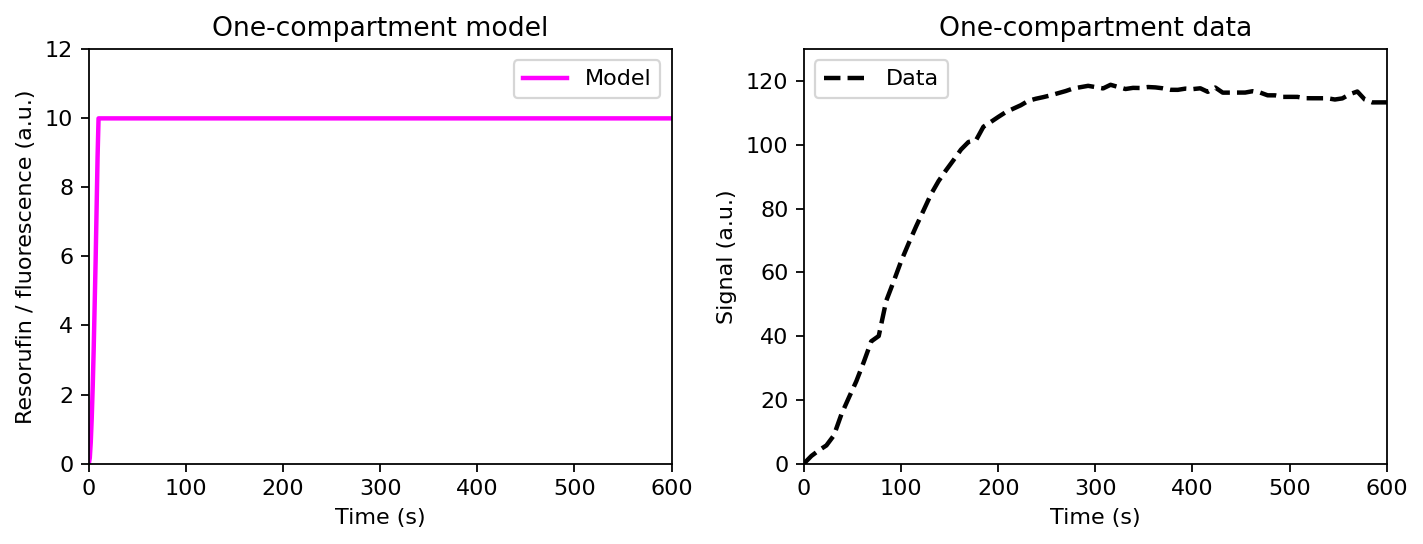

In [ ]:
# note: plot one-compartment model results side-by-side w/ one-compartment data.
comp1_time_col = find_col(Results_comp1, "time")
comp1_res_col = find_col(Results_comp1, "resorufin", exact="resorufin_Internal")

data1_time_col = "Time"
data1_signal_col = "+stachyose"

plot_model_vs_data_side_by_side(
    model_time=Results_comp1[comp1_time_col],
    model_y=Results_comp1[comp1_res_col],
    data_time=df_comp1[data1_time_col],
    data_y=df_comp1[data1_signal_col],
    model_title="One-compartment model",
    data_title="One-compartment data",
    filename="fig_1B_one_compartment_model_vs_data.png",
    model_ylabel="Resorufin / fluorescence (a.u.)",
    data_ylabel="Signal (a.u.)",
    model_ymax=12,
    data_ymax=130
)

**One-compartment interpretation.**  
The one-compartment model produces a fast increase in resorufin, while the experimental data increases more gradually before leveling off. This means the model captures the idea that fluorescence should increase over time, but it does not capture the slower experimental timescale. The increasing trend is still useful because it shows that the cascade is active, but the timing and shape do not fully match the data.

In [ ]:
# note:
# Before interpreting the final fluorescence output, check whether important species actually move or appear in the one-compartment model.
species_to_check_comp1 = [
    "stachyose_External",
    "stachyose_Internal",
    "glucose_Internal",
    "H2O2_Internal",
    "resorufin_Internal"
]

for col in species_to_check_comp1:
    if col in Results_comp1.columns:
        print(col)
        print("  min:", Results_comp1[col].min())
        print("  max:", Results_comp1[col].max())
        print()
    else:
        print("Missing:", col)

stachyose_External
  min: 24517.747539989676
  max: 50000.0

stachyose_Internal
  min: 0.0
  max: 24953.211307401165

glucose_Internal
  min: 0.0
  max: 962.4403463429442

H2O2_Internal
  min: 0.0
  max: 0.10000000466700354

resorufin_Internal
  min: 0.0
  max: 10.000000000067187



Saved: cleaned_notebook_figures/fig_1B_one_compartment_sanity_checks.png


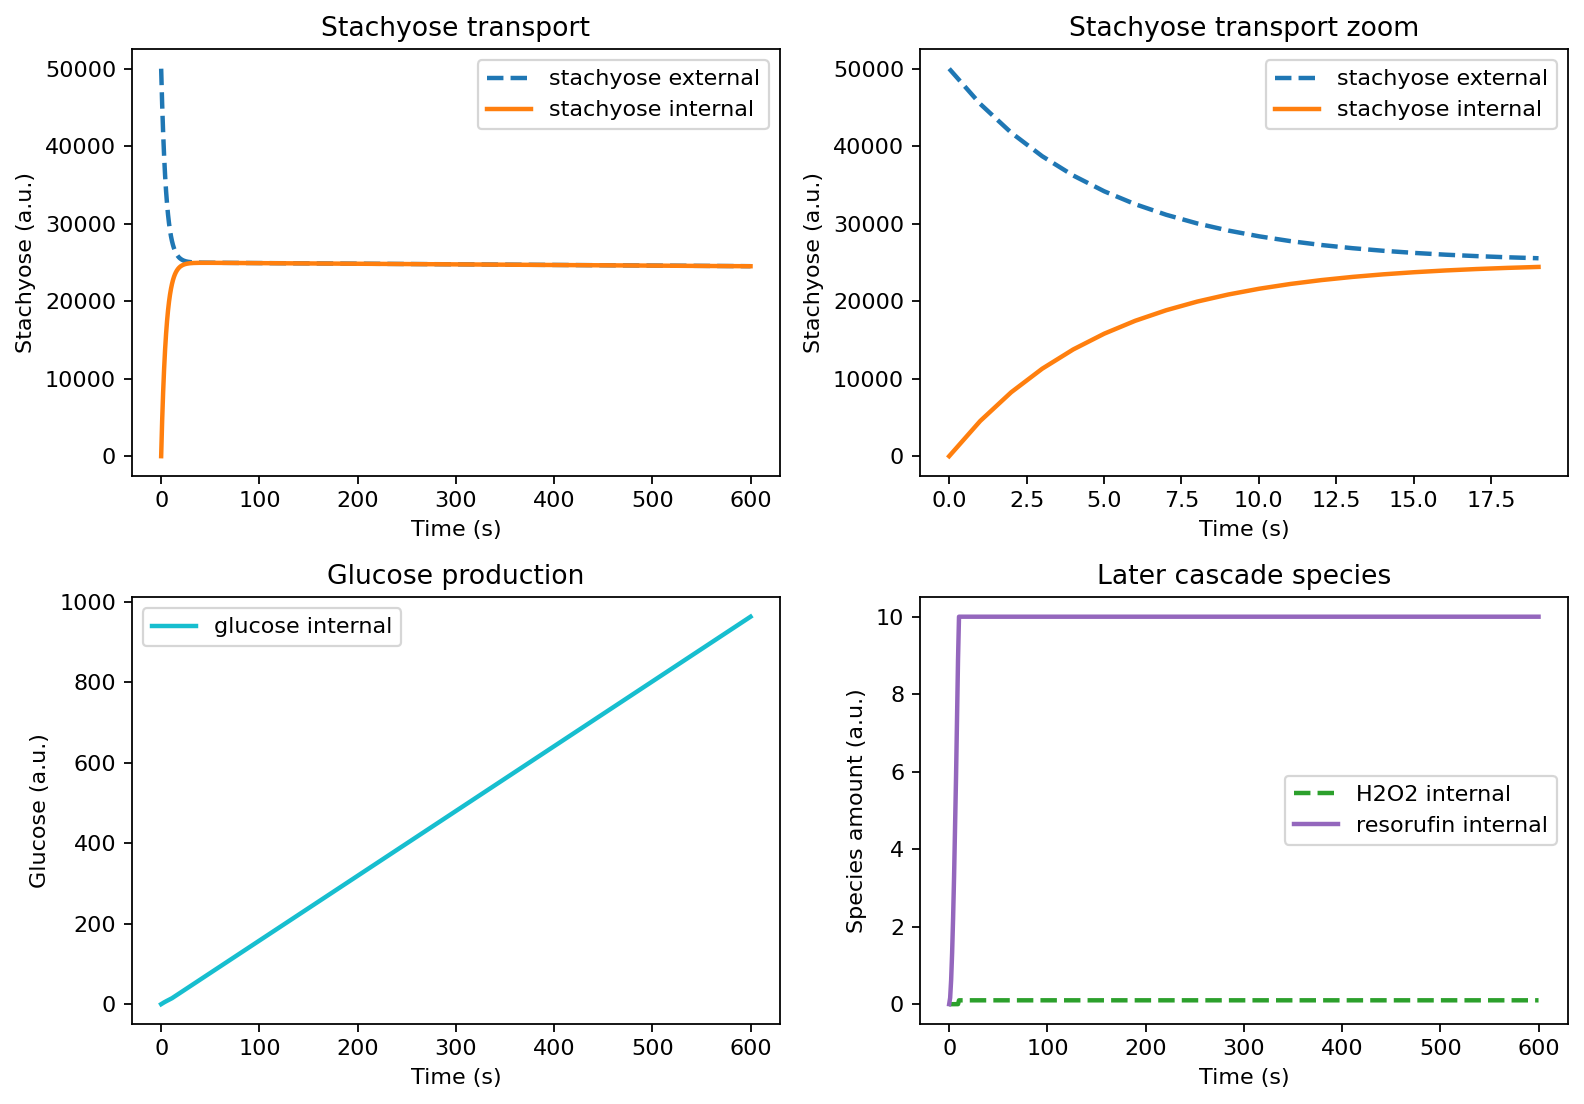

In [ ]:
# note:
# One-compartment sanity checks:
# 1. stachyose should move from external to internal
# 2. glucose should appear after stachyose processing
# 3. H2O2 and resorufin help show later cascade behavior

# Find time column to use for all plots 
comp1_time_col = find_col(Results_comp1, "time")

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# 1. Stachyose transport
axes[0, 0].plot(
    Results_comp1[comp1_time_col],
    Results_comp1["stachyose_External"],
    color=COLOR_EXTERNAL,
    linestyle="--",
    linewidth=2,
    label="stachyose external"
)

axes[0, 0].plot(
    Results_comp1[comp1_time_col],
    Results_comp1["stachyose_Internal"],
    color=COLOR_INTERNAL,
    linestyle="-",
    linewidth=2,
    label="stachyose internal"
)

axes[0, 0].set_title("Stachyose transport")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Stachyose (a.u.)")
axes[0, 0].legend()


# 2. Early-time stachyose transport zoom
early_mask = Results_comp1[comp1_time_col] <= 20

axes[0, 1].plot(
    Results_comp1.loc[early_mask, comp1_time_col],
    Results_comp1.loc[early_mask, "stachyose_External"],
    color=COLOR_EXTERNAL,
    linestyle="--",
    linewidth=2,
    label="stachyose external"
)

axes[0, 1].plot(
    Results_comp1.loc[early_mask, comp1_time_col],
    Results_comp1.loc[early_mask, "stachyose_Internal"],
    color=COLOR_INTERNAL,
    linestyle="-",
    linewidth=2,
    label="stachyose internal"
)

axes[0, 1].set_title("Stachyose transport zoom")
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].set_ylabel("Stachyose (a.u.)")
axes[0, 1].legend()


# 3. Glucose production
axes[1, 0].plot(
    Results_comp1[comp1_time_col],
    Results_comp1["glucose_Internal"],
    color=COLOR_GLUCOSE,
    linestyle="-",
    linewidth=2,
    label="glucose internal"
)

axes[1, 0].set_title("Glucose production")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Glucose (a.u.)")
axes[1, 0].legend()


# 4. Later cascade species
axes[1, 1].plot(
    Results_comp1[comp1_time_col],
    Results_comp1["H2O2_Internal"],
    color=COLOR_H2O2,
    linestyle="--",
    linewidth=2,
    label="H2O2 internal"
)

axes[1, 1].plot(
    Results_comp1[comp1_time_col],
    Results_comp1["resorufin_Internal"],
    color=COLOR_RESORUFIN,
    linestyle="-",
    linewidth=2,
    label="resorufin internal"
)

axes[1, 1].set_title("Later cascade species")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("Species amount (a.u.)")
axes[1, 1].legend()


fig.tight_layout()
save_fig(fig, "fig_1B_one_compartment_sanity_checks.png")
plt.show()

**One-compartment sanity checks interpretation.**  External stachyose goes down while internal stachyose goes up, so transport is happening. Glucose increases, so the aGlc conversion step is active. The later-species panel shows the downstream cascade activates, but it happens much faster/simpler than the experimental data

## Two-Compartment Model

In [ ]:
# note:
# build the two-compartment CRN before simulating it.

# Build Vesicle 2: glucose transport helper
External_2 = "Internal"   # Vesicle 2 sits inside the main internal space

ahl_monomer_c2 = IntegralMembraneProtein(
    "ahl_monomer",
    product="aHL",
    compartment="c2"
)

# glucose transport into c2
ahl_glucose_c2 = MembraneChannel(
    ahl_monomer_c2.product,
    substrate="glucose",
    external_compartment=External_2,
    internal_compartment="c2"
)

mech_transport = Simple_Transport()

glucose_transport_mechanisms = {
    mech_transport.mechanism_type: mech_transport,
}

M_glucose = Mixture(
    "Catalysis Mixture",
    components=[ahl_glucose_c2],
    parameter_file=PARAMETER_FILE,
    mechanisms=glucose_transport_mechanisms
)

CRN_glucose = M_glucose.compile_crn()


#Build Vesicle 2: stachyose transport + aGlc + GOx

# H2O2 can move between c2 and the main internal space
h2o2_c2 = DiffusibleMolecule(
    "H2O2",
    external_compartment=External_2,
    internal_compartment="c2"
)

# stachyose transport into c2
ahl_stachyose_c2 = MembraneChannel(
    ahl_monomer_c2.product,
    substrate="stachyose",
    external_compartment=External_2,
    internal_compartment="c2"
)

# aGlc converts stachyose into glucose in c2
aGlc_c2 = EnzymeCompartment(
    "aGlc",
    substrates=ahl_stachyose_c2.substrate,
    products=["byproduct", ahl_glucose_c2.substrate],
    compartment=ahl_glucose_c2.substrate.compartment.name
)

# GOx uses glucose and oxygen to produce H2O2 in c2
GOx_c2 = EnzymeCompartment(
    "GOx",
    substrates=[aGlc_c2.products[1], "O2"],
    products=[h2o2_c2.substrate, "gluconolactone"],
    compartment=ahl_stachyose_c2.substrate.compartment.name
)

mech_cat = MichaelisMenten()
mech_transport = Simple_Transport()
mech_diffusion = Simple_Diffusion()

all_mechanisms_c2 = {
    mech_cat.mechanism_type: mech_cat,
    mech_transport.mechanism_type: mech_transport,
    mech_diffusion.mechanism_type: mech_diffusion,
}

M2 = Mixture(
    "Catalysis Mixture",
    components=[h2o2_c2, ahl_stachyose_c2, aGlc_c2, GOx_c2],
    parameter_file=PARAMETER_FILE,
    mechanisms=all_mechanisms_c2
)

CRN2 = M2.compile_crn()


# Add glucose transport species and reactions into Vesicle 2 CRN
for species in CRN_glucose.species:
    if species not in CRN2.species:
        CRN2.add_species(species)

for rxn in CRN_glucose.reactions:
    if rxn not in CRN2.reactions:
        CRN2.add_reactions(rxn)



# Build Vesicle 1: main internal space
ahl_monomer_main = IntegralMembraneProtein(
    "ahl_monomer",
    product="aHL",
    compartment="Internal"
)

# stachyose transport from outside into the main internal space
ahl_stachyose_main = MembraneChannel(
    ahl_monomer_main.product,
    substrate="stachyose"
)

# HRP uses H2O2 and AUR in the main internal space to make resorufin
HRP_main = EnzymeCompartment(
    "HRP",
    substrates=[h2o2_c2.product, "AUR"],
    products=["O2", "resorufin"],
    compartment=ahl_stachyose_main.substrate.compartment.name
)

all_mechanisms_main = {
    mech_cat.mechanism_type: mech_cat,
    mech_transport.mechanism_type: mech_transport,
}

M1 = Mixture(
    "Catalysis Mixture",
    components=[ahl_stachyose_main, HRP_main],
    parameter_file=PARAMETER_FILE,
    mechanisms=all_mechanisms_main
)

CRN_comp2 = M1.compile_crn()


# Combine Vesicle 2 CRN into main CRN
for species in CRN2.species:
    if species not in CRN_comp2.species:
        CRN_comp2.add_species(species)

for rxn in CRN2.reactions:
    if rxn not in CRN_comp2.reactions:
        CRN_comp2.add_reactions(rxn)

# note: check the combined two-compartment CRN num species and reactions before simulating it.
print("Number of species:", len(CRN_comp2.species))
print("Number of reactions:", len(CRN_comp2.reactions))

Number of species: 20
Number of reactions: 10


In [ ]:
# note:
# simulate the two-compartment model and load the matching experimental data
df_comp2 = pd.read_excel(
    os.path.join(directory, DATA_FILE),
    sheet_name="Compartment_2"
).copy()

df_comp2.columns = df_comp2.columns.str.strip()

# preserve helper names used in the working notebook
df_comp2["timepoints"] = df_comp2["Time"]
df_comp2["data_scaled"] = df_comp2["+stachyose"] / 12

initial_conc_comp2 = {
    "stachyose_External": 50000,

    # Vesicle 1 / main internal space
    "protein_aHL_Passive_Membrane": 1,
    "AUR_Internal": 10,
    "protein_HRP_Internal": 10,

    # Vesicle 2 / inner reaction space
    "protein_GOx_c2": 1,
    "O2_c2": 1,
    "protein_aGlc_c2": 1.7,
}

Results_comp2 = CRN_comp2.simulate_with_bioscrape_via_sbml(
    timepoints,
    initial_condition_dict=initial_conc_comp2
)

print("Two-compartment result columns:")
print(Results_comp2.columns.tolist())

Results_comp2.head()

Two-compartment result columns:
['protein_aHL_Passive_Membrane', 'stachyose_Internal', 'stachyose_External', 'protein_HRP_Internal', 'H2O2_Internal', 'AUR_Internal', 'O2_Internal', 'resorufin_Internal', 'complex_AUR_Internal_H2O2_Internal_protein_HRP_Internal_', 'H2O2_c2', 'stachyose_c2', 'protein_aGlc_c2', 'byproduct_c2', 'glucose_c2', 'complex_protein_aGlc_c2_stachyose_c2_', 'protein_GOx_c2', 'O2_c2', 'gluconolactone_c2', 'complex_O2_c2_glucose_c2_protein_GOx_c2_', 'glucose_Internal', 'time']


,protein_aHL_Passive_Membrane,stachyose_Internal,stachyose_External,protein_HRP_Internal,H2O2_Internal,AUR_Internal,O2_Internal,resorufin_Internal,complex_AUR_Internal_H2O2_Internal_protein_HRP_Internal_,H2O2_c2,...,protein_aGlc_c2,byproduct_c2,glucose_c2,complex_protein_aGlc_c2_stachyose_c2_,protein_GOx_c2,O2_c2,gluconolactone_c2,complex_O2_c2_glucose_c2_protein_GOx_c2_,glucose_Internal,time
0,1.0,50.000000,50000.000000,10.000000,0.000000e+00,10.000000,0.100000,0.000000,0.000000,0.000000,...,1.700000,0.000000,0.000000,0.000000,1.0,1.000000e+00,0.0,0.000000e+00,0.000000,0.000000
1,1.0,4360.859367,45458.378212,9.999985,8.606838e-07,9.990656,0.109330,0.009330,0.000015,0.990655,...,0.083972,183.698709,176.350335,1.616028,1.0,-1.842223e-15,1.0,9.608501e-16,6.348374,1.001669
2,1.0,7529.953075,41702.554634,9.999986,8.529486e-07,9.980782,0.119204,0.019204,0.000014,0.980781,...,0.011727,475.975782,439.568095,1.688273,1.0,-1.440217e-25,1.0,1.892799e-23,35.407686,2.003339
3,1.0,9850.949755,38563.660892,9.999986,8.452754e-07,9.971007,0.128979,0.028979,0.000014,0.971006,...,0.004647,772.519861,685.526970,1.695353,1.0,-1.437341e-31,1.0,1.199932e-31,85.992891,3.005008
4,1.0,11543.832446,35913.240045,9.999986,8.376638e-07,9.961329,0.138657,0.038657,0.000014,0.961328,...,0.002633,1069.737047,914.386791,1.697367,1.0,1.717565e-34,1.0,-6.690244e-36,154.350256,4.006678


Saved: cleaned_notebook_figures/fig_1C_two_compartment_model_vs_data.png


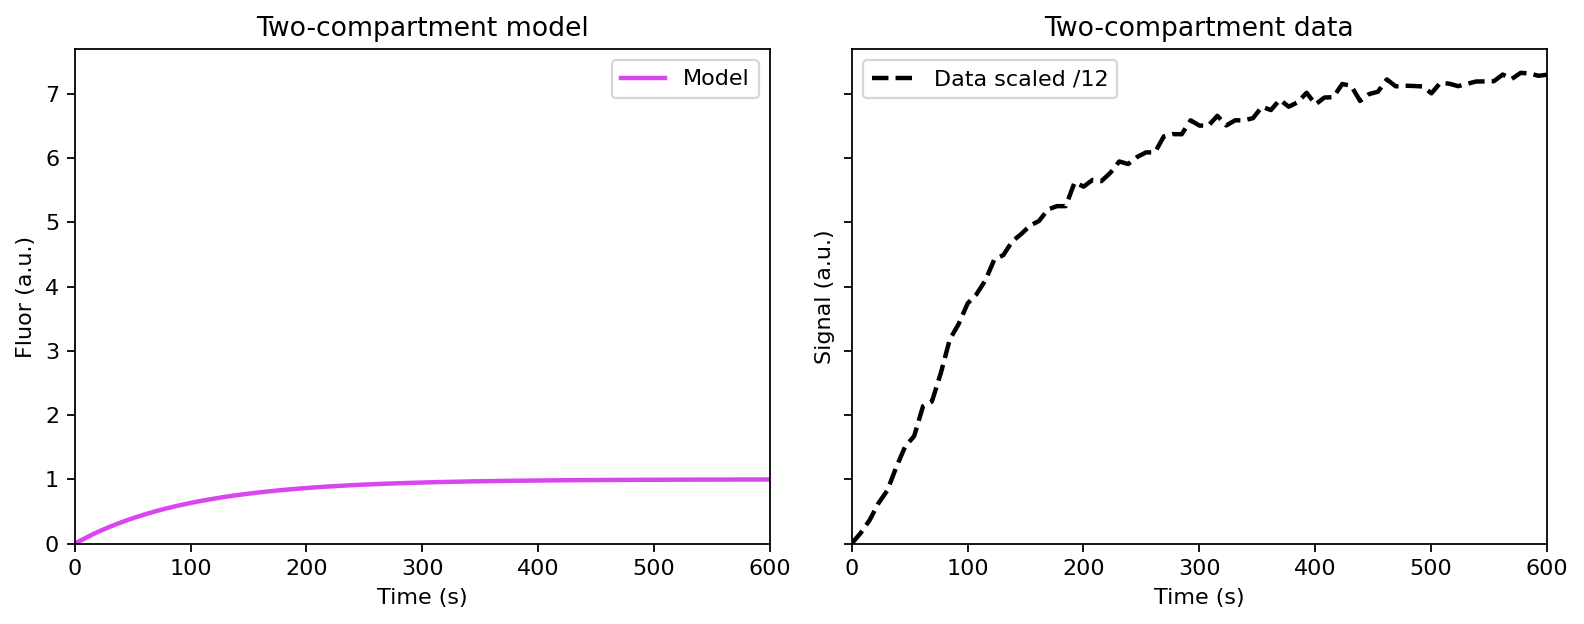

In [51]:
# note:
# Two-compartment model-vs-data side-by-side plot.
# Use the SAME y-scale on both panels so the mismatch is visible.

comp2_time_col = find_col(Results_comp2, "time")
comp2_res_col = find_col(Results_comp2, "resorufin")

data2_time_col = "timepoints"
data2_signal_col = "data_scaled"

model_y = Results_comp2[comp2_res_col]
data_y = df_comp2[data2_signal_col]

shared_ymax = max(model_y.max(), data_y.max()) * 1.05

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].plot(
    Results_comp2[comp2_time_col],
    model_y,
    color=COLOR_MODEL,
    linewidth=2,
    label="Model"
)

axes[0].set_title("Two-compartment model")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Fluor (a.u.)")
axes[0].set_xlim(0, 600)
axes[0].set_ylim(0, shared_ymax)
axes[0].legend()

axes[1].plot(
    df_comp2[data2_time_col],
    data_y,
    color=COLOR_DATA,
    linestyle="--",
    linewidth=2,
    label="Data scaled /12"
)

axes[1].set_title("Two-compartment data")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Signal (a.u.)")  
axes[1].set_xlim(0, 600)
axes[1].set_ylim(0, shared_ymax)
axes[1].legend()

fig.tight_layout()
save_fig(fig, "fig_1C_two_compartment_model_vs_data.png")
plt.show()

**Two-compartment interpretation.**  
The two-compartment model produces a much smaller resorufin signal than the experimental data, but the simulated output still increases over time. This means the modeled cascade is active rather than completely failing. However, the experimental data rises more strongly and reaches a much larger fluorescence magnitude. The side-by-side comparison suggests that adding a second compartment changes the cascade behavior, but the current parameter setup still does not fully capture the experimental fluorescence scale.

Saved: cleaned_notebook_figures/fig_1D_two_compartment_sanity_checks.png


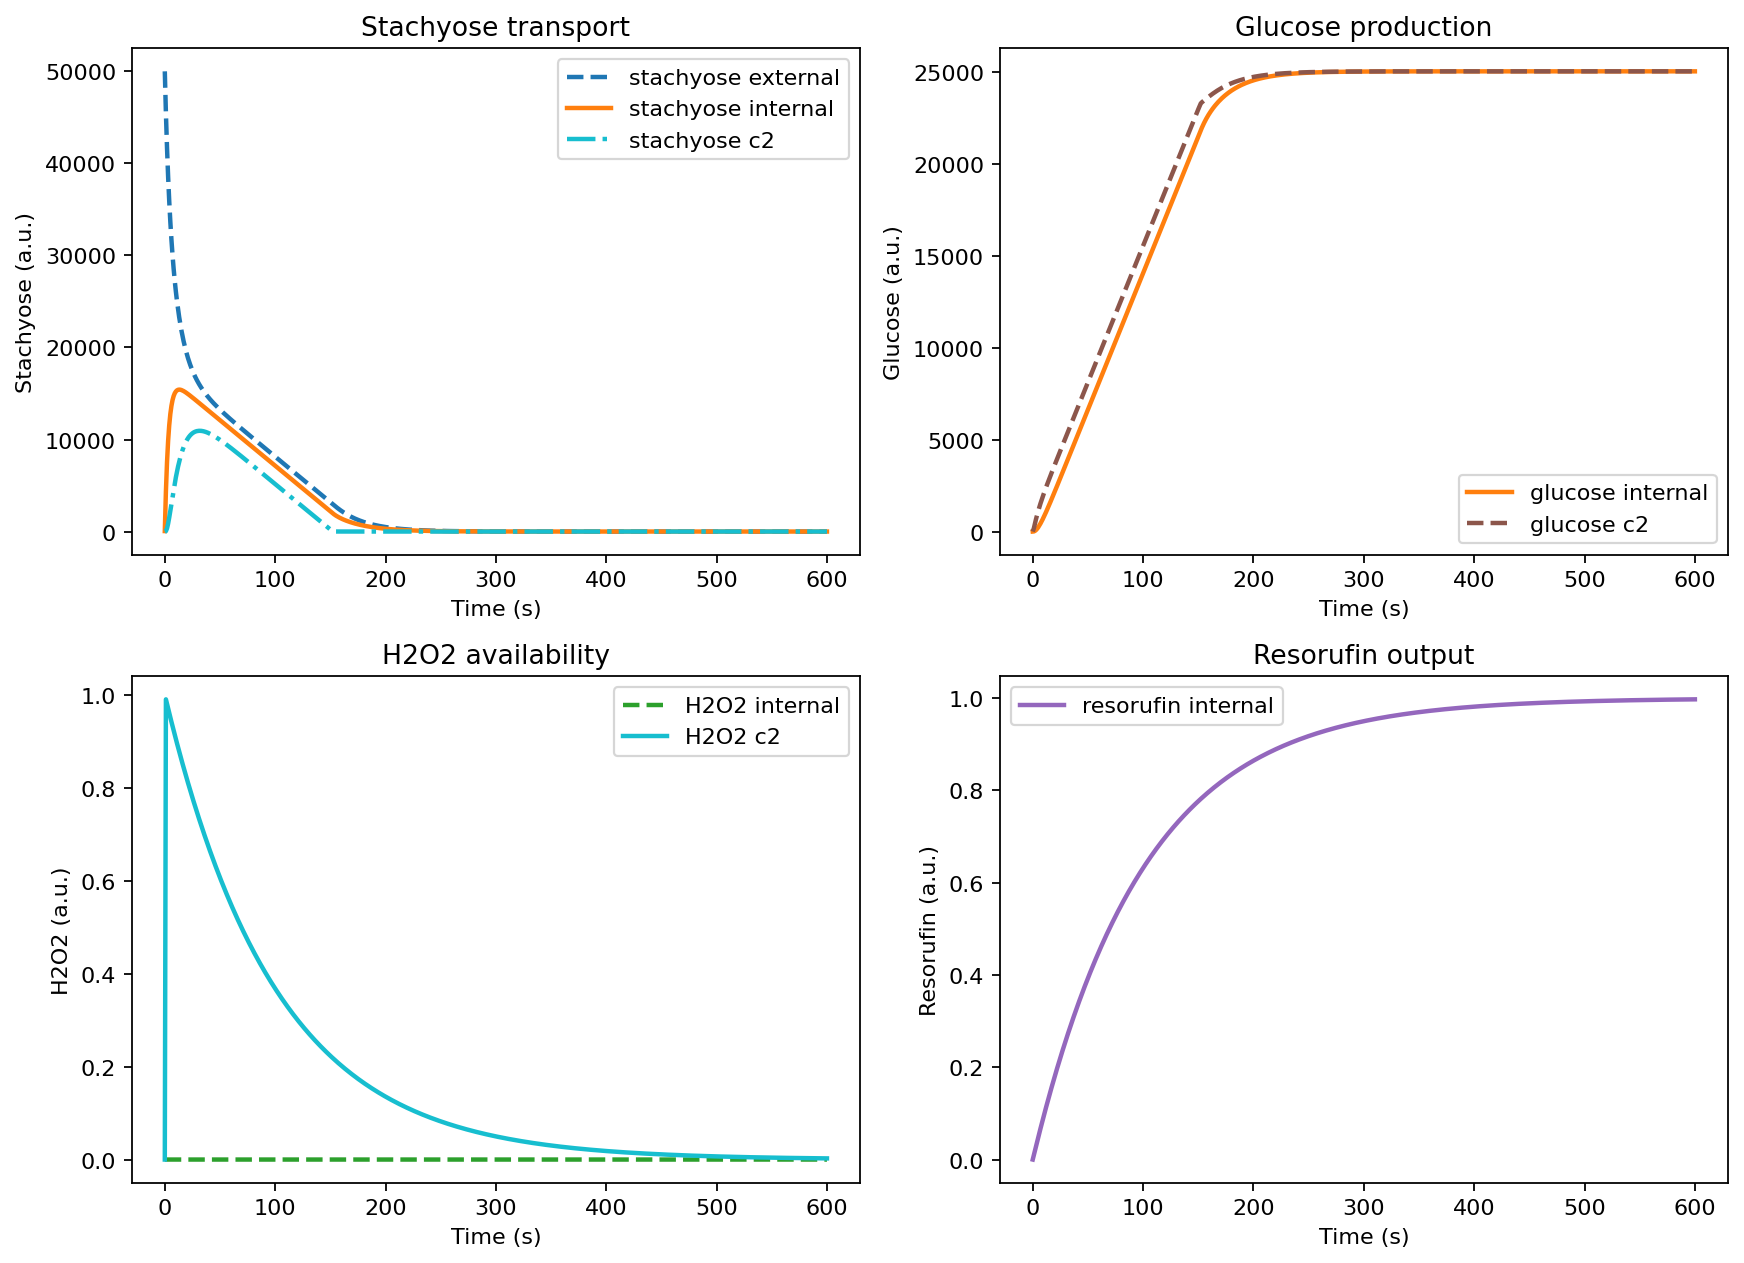

In [ ]:
# note:
# Two-compartment sanity checks:
# 1. stachyose transport across compartments
# 2. glucose production in c2 and appearance in internal space
# 3. H2O2 in c2 and internal space
# 4. final resorufin output in the internal space

if "Results_comp2" not in globals():
    raise NameError(
        "Results_comp2 is not defined yet. Run the two-compartment build cell and simulation cell first."
    )

comp2_time_col = find_col(Results_comp2, "time", exact="time")

COLOR_C2 = "#17becf"        
COLOR_GLUCOSE = "#8c564b"   

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# 1. Stachyose transport
axes[0, 0].plot(
    Results_comp2[comp2_time_col],
    Results_comp2["stachyose_External"],
    color=COLOR_EXTERNAL,
    linestyle="--",
    linewidth=2,
    label="stachyose external"
)

axes[0, 0].plot(
    Results_comp2[comp2_time_col],
    Results_comp2["stachyose_Internal"],
    color=COLOR_INTERNAL,
    linestyle="-",
    linewidth=2,
    label="stachyose internal"
)

axes[0, 0].plot(
    Results_comp2[comp2_time_col],
    Results_comp2["stachyose_c2"],
    color=COLOR_C2,
    linestyle="-.",
    linewidth=2,
    label="stachyose c2"
)

axes[0, 0].set_title("Stachyose transport")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Stachyose (a.u.)")
axes[0, 0].legend()

# 2. Glucose
axes[0, 1].plot(
    Results_comp2[comp2_time_col],
    Results_comp2["glucose_Internal"],
    color=COLOR_INTERNAL,
    linestyle="-",
    linewidth=2,
    label="glucose internal"
)

axes[0, 1].plot(
    Results_comp2[comp2_time_col],
    Results_comp2["glucose_c2"],
    color=COLOR_GLUCOSE,
    linestyle="--",
    linewidth=2,
    label="glucose c2"
)

axes[0, 1].set_title("Glucose production")
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].set_ylabel("Glucose (a.u.)")
axes[0, 1].legend()

# 3. H2O2
axes[1, 0].plot(
    Results_comp2[comp2_time_col],
    Results_comp2["H2O2_Internal"],
    color=COLOR_H2O2,
    linestyle="--",
    linewidth=2,
    label="H2O2 internal"
)

axes[1, 0].plot(
    Results_comp2[comp2_time_col],
    Results_comp2["H2O2_c2"],
    color=COLOR_C2,
    linestyle="-",
    linewidth=2,
    label="H2O2 c2"
)

axes[1, 0].set_title("H2O2 availability")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("H2O2 (a.u.)")
axes[1, 0].legend()

# 4. Resorufin
axes[1, 1].plot(
    Results_comp2[comp2_time_col],
    Results_comp2["resorufin_Internal"],
    color=COLOR_RESORUFIN,
    linestyle="-",
    linewidth=2,
    label="resorufin internal"
)

axes[1, 1].set_title("Resorufin output")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("Resorufin (a.u.)")
axes[1, 1].legend()

fig.tight_layout()
save_fig(fig, "fig_1D_two_compartment_sanity_checks.png")
plt.show()

**Two-compartment sanity-check interpretation.**  
The two-compartment sanity-check plots show that the modeled cascade is active across compartments. Stachyose goes down in the external space and appears in the internal space and in c2, showing that transport is occurring. Glucose is produced in c2 and also appears in the internal space, consistent with downstream processing after stachyose transport. H2O2 is generated in c2 and remains available as an intermediate, while resorufin in the internal space increases over time, confirming that the model reaches the final fluorescence-producing step. Together, these sanity checks suggest that the two-compartment cascade is functioning mechanistically, even though the model-vs-data comparison shows that the simulated fluorescence magnitude is still smaller than the experimental signal.

In [ ]:
# note:
# Three-compartment model

# Compartment roles:
# External = outside the full MVV system
# Internal_1 = outer/main vesicle interior with HRP + AUR
# Internal_2a = GOx inner vesicle
# Internal_2b = aGlc inner vesicle

from biocrnpyler import *
from biocrnpyler.components import Component
from biocrnpyler.core.compartment import Compartment
from biocrnpyler.core.mixture import Mixture
from biocrnpyler.components.membrane import (
    IntegralMembraneProtein,
    MembraneChannel,
    DiffusibleMolecule
)


class EnzymeCompartment(Component):
    """
    Helper class for enzyme reactions with multiple substrates/products
    inside a specified compartment.
    """

    def __init__(
        self,
        enzyme,
        substrates,
        products,
        compartment=None,
        attributes=None,
        **keywords
    ):
        if compartment is None:
            compartment = "default"

        self.enzyme = self.set_species(
            enzyme,
            material_type="protein",
            compartment=compartment,
            attributes=attributes
        )

        self.substrates = substrates
        self.products = products

        Component.__init__(self, name=self.enzyme.name, **keywords)

    @property
    def substrates(self):
        return self._substrates

    @substrates.setter
    def substrates(self, new_substrates):
        compartment = self.enzyme.compartment.name

        if not isinstance(new_substrates, list):
            new_substrates = [new_substrates]

        self._substrates = [
            self.set_species(s, compartment=compartment)
            for s in new_substrates
        ]

    @property
    def products(self):
        return self._products

    @products.setter
    def products(self, new_products):
        compartment = self.enzyme.compartment.name

        if not isinstance(new_products, list):
            new_products = [new_products]

        self._products = [
            self.set_species(p, compartment=compartment)
            for p in new_products
        ]

    def update_species(self):
        mech_cat = self.get_mechanism("catalysis")

        return mech_cat.update_species(
            enzyme=self.enzyme,
            substrate=self.substrates,
            product=self.products
        )

    def update_reactions(self):
        mech_cat = self.get_mechanism("catalysis")

        return mech_cat.update_reactions(
            enzyme=self.enzyme,
            substrate=self.substrates,
            product=self.products,
            component=self,
            part_id=self.name
        )


def make_compartment_marker(tag):
    """
    Create a compartment marker used for membrane-protein placement.
    """
    compartment = Compartment(name=f"compartment_{tag}")
    compartment._name = str(tag)
    return compartment


def merge_crns(target_crn, source_crn):
    """
    Add species and reactions from one CRN into another.
    """
    for species in source_crn.species:
        if species not in target_crn.species:
            target_crn.add_species(species)

    for reaction in source_crn.reactions:
        if reaction not in target_crn.reactions:
            target_crn.add_reactions(reaction)


def build_three_compartment_model(parameter_file=PARAMETER_FILE):
    """
    Build and compile the three-compartment MVV cascade model.
    """

    membrane_marker_1 = make_compartment_marker("1")
    membrane_marker_2b = make_compartment_marker("2b")

    mech_cat = MichaelisMenten()
    mech_transport = Simple_Transport()
    mech_diffusion = Simple_Diffusion()

    mechanisms_comp3 = {
        mech_cat.mechanism_type: mech_cat,
        mech_transport.mechanism_type: mech_transport,
        mech_diffusion.mechanism_type: mech_diffusion,
    }

    # Shared diffusible species

    h2o2_2a = DiffusibleMolecule(
        "H2O2",
        external_compartment="Internal_1",
        internal_compartment="Internal_2a"
    )

    o2_2a = DiffusibleMolecule(
        "O2",
        external_compartment="External",
        internal_compartment="Internal_2a"
    )

    glucose_2b = DiffusibleMolecule(
        "glucose",
        external_compartment="Internal_1",
        internal_compartment="Internal_2b"
    )

    # Main MVV interior: stachyose entry + HRP/AUR fluorescence step
    ahl_monomer_1 = IntegralMembraneProtein(
        "ahl_monomer",
        product="aHL",
        compartment=membrane_marker_1
    )

    ahl_stachyose_1 = MembraneChannel(
        ahl_monomer_1.product,
        substrate="stachyose",
        external_compartment="External",
        internal_compartment="Internal_1"
    )

    HRP_1 = EnzymeCompartment(
        "HRP",
        substrates=[h2o2_2a.product, "AUR"],
        products=["O2", "resorufin"],
        compartment="Internal_1"
    )

    M_main = Mixture(
        "Catalysis Mixture",
        components=[ahl_stachyose_1, HRP_1],
        parameter_file=parameter_file,
        mechanisms=mechanisms_comp3
    )

    CRN_comp3 = M_main.compile_crn()

    # GOx inner vesicle: glucose to H2O2
    ompF_monomer = IntegralMembraneProtein(
        "OmpF",
        product="OmpF"
    )

    ompF_glucose_2a = MembraneChannel(
        ompF_monomer.product,
        substrate="glucose",
        external_compartment="Internal_1",
        internal_compartment="Internal_2a"
    )

    GOx_2a = EnzymeCompartment(
        "GOx",
        substrates=[ompF_glucose_2a.substrate, o2_2a.substrate],
        products=[h2o2_2a.substrate, "gluconolactone"],
        compartment="Internal_2a"
    )

    M_gox = Mixture(
        "Catalysis Mixture",
        components=[h2o2_2a, o2_2a, ompF_glucose_2a, GOx_2a],
        parameter_file=parameter_file,
        mechanisms=mechanisms_comp3
    )

    CRN_gox = M_gox.compile_crn()
    merge_crns(CRN_comp3, CRN_gox)

    # aGlc inner vesicle: stachyose to glucose

    ahl_monomer_2b = IntegralMembraneProtein(
        "ahl_monomer",
        product="aHL",
        compartment=membrane_marker_2b
    )

    ahl_stachyose_2b = MembraneChannel(
        ahl_monomer_2b.product,
        substrate="stachyose",
        external_compartment="Internal_1",
        internal_compartment="Internal_2b"
    )

    aGlc_2b = EnzymeCompartment(
        "aGlc",
        substrates=ahl_stachyose_2b.substrate,
        products=["byproduct", glucose_2b.substrate],
        compartment="Internal_2b"
    )

    M_aglc = Mixture(
        "Catalysis Mixture",
        components=[glucose_2b, ahl_stachyose_2b, aGlc_2b],
        parameter_file=parameter_file,
        mechanisms=mechanisms_comp3
    )

    CRN_aglc = M_aglc.compile_crn()
    merge_crns(CRN_comp3, CRN_aglc)

    return CRN_comp3


CRN_comp3 = build_three_compartment_model()

# note: check three-compartment CRN num species and reactions before simulating it.
print("Number of species:", len(CRN_comp3.species))
print("Number of reactions:", len(CRN_comp3.reactions))

print("\nKey three-compartment species:")
for species in CRN_comp3.species:
    name = str(species)
    if (
        "stachyose" in name
        or "glucose" in name
        or "H2O2" in name
        or "resorufin" in name
        or "aHL" in name
        or "OmpF" in name
        or "GOx" in name
        or "aGlc" in name
        or "HRP" in name
        or "AUR" in name
        or "O2" in name
    ):
        print(name)

Number of species: 23
Number of reactions: 12

Key three-compartment species:
protein_aHL_Passive_Membrane
stachyose_Internal_1
stachyose_External
protein_HRP_Internal_1
H2O2_Internal_1
AUR_Internal_1
O2_Internal_1
resorufin_Internal_1
complex_AUR_Internal_1_H2O2_Internal_1_protein_HRP_Internal_1_
H2O2_Internal_2a
O2_Internal_2a
O2_External
protein_OmpF_Passive_Membrane
glucose_Internal_2a
glucose_Internal_1
protein_GOx_Internal_2a
complex_O2_Internal_2a_glucose_Internal_2a_protein_GOx_Internal_2a_
glucose_Internal_2b
stachyose_Internal_2b
protein_aGlc_Internal_2b
complex_protein_aGlc_Internal_2b_stachyose_Internal_2b_


In [43]:
# note:
# Simulate the three-compartment model and load the matching experimental data.

df_comp3 = pd.read_excel(
    os.path.join(directory, DATA_FILE),
    sheet_name="Compartment_3"
).copy()

df_comp3.columns = df_comp3.columns.str.strip()

data3_time_col = find_col(df_comp3, "Time", exact="Time")
data3_signal_col = find_col(df_comp3, "stachyose", exact="+stachyose")

df_comp3["timepoints"] = df_comp3[data3_time_col]
df_comp3["data_scaled"] = df_comp3[data3_signal_col] / 12

species_names_comp3 = [str(s) for s in CRN_comp3.species]

initial_conc_comp3 = {
    "stachyose_External": 50000,
    "stachyose_Internal_1": 50,

    "protein_aHL_Passive_Membrane": 1,
    "AUR_Internal_1": 10,
    "protein_HRP_Internal_1": 10,
    "O2_Internal_1": 0.1,

    "protein_OmpF_Passive_Membrane": 1,
    "protein_GOx_Internal_2a": 0.0051,
    "O2_Internal_2a": 0.1,

    "protein_aGlc_Internal_2b": 0.0092,
}

if "O2_External" in species_names_comp3:
    initial_conc_comp3["O2_External"] = 0

initial_conc_comp3 = {
    species: value
    for species, value in initial_conc_comp3.items()
    if species in species_names_comp3
}

print("Initial conditions used:")
for species, value in initial_conc_comp3.items():
    print(species, "=", value)

Results_comp3 = CRN_comp3.simulate_with_bioscrape_via_sbml(
    timepoints,
    initial_condition_dict=initial_conc_comp3
)

print("\nThree-compartment result columns:")
print(Results_comp3.columns.tolist())

print("\nKey output checks:")
for col in Results_comp3.columns:
    if (
        "stachyose" in col
        or "glucose" in col
        or "H2O2" in col
        or "resorufin" in col
    ):
        print(col, "max =", Results_comp3[col].max())

Results_comp3.head()

Initial conditions used:
stachyose_External = 50000
stachyose_Internal_1 = 50
protein_aHL_Passive_Membrane = 1
AUR_Internal_1 = 10
protein_HRP_Internal_1 = 10
O2_Internal_1 = 0.1
protein_OmpF_Passive_Membrane = 1
protein_GOx_Internal_2a = 0.0051
O2_Internal_2a = 0.1
protein_aGlc_Internal_2b = 0.0092
O2_External = 0

Three-compartment result columns:
['protein_aHL_Passive_Membrane', 'stachyose_Internal_1', 'stachyose_External', 'protein_HRP_Internal_1', 'H2O2_Internal_1', 'AUR_Internal_1', 'O2_Internal_1', 'resorufin_Internal_1', 'complex_AUR_Internal_1_H2O2_Internal_1_protein_HRP_Internal_1_', 'H2O2_Internal_2a', 'O2_Internal_2a', 'O2_External', 'protein_OmpF_Passive_Membrane', 'glucose_Internal_2a', 'glucose_Internal_1', 'protein_GOx_Internal_2a', 'gluconolactone_Internal_2a', 'complex_O2_Internal_2a_glucose_Internal_2a_protein_GOx_Internal_2a_', 'glucose_Internal_2b', 'stachyose_Internal_2b', 'protein_aGlc_Internal_2b', 'byproduct_Internal_2b', 'complex_protein_aGlc_Internal_2b_stach

,protein_aHL_Passive_Membrane,stachyose_Internal_1,stachyose_External,protein_HRP_Internal_1,H2O2_Internal_1,AUR_Internal_1,O2_Internal_1,resorufin_Internal_1,complex_AUR_Internal_1_H2O2_Internal_1_protein_HRP_Internal_1_,H2O2_Internal_2a,...,glucose_Internal_1,protein_GOx_Internal_2a,gluconolactone_Internal_2a,complex_O2_Internal_2a_glucose_Internal_2a_protein_GOx_Internal_2a_,glucose_Internal_2b,stachyose_Internal_2b,protein_aGlc_Internal_2b,byproduct_Internal_2b,complex_protein_aGlc_Internal_2b_stachyose_Internal_2b_,time
0,1.0,50.000000,50000.000000,10.0,0.000000e+00,10.000000,0.100000,0.000000e+00,0.000000e+00,0.000000,...,0.000000,0.005100,0.000000,0.000000e+00,0.000000,0.000000,0.009200,0.000000,0.000000,0.000000
1,1.0,4367.169422,45458.544177,10.0,1.687705e-12,10.000000,0.100000,3.570530e-09,2.850207e-11,0.000002,...,0.005978,0.005100,0.000002,9.406396e-09,1.382340,222.888802,0.000096,1.388495,0.009104,1.001669
2,1.0,7563.669557,41704.468121,10.0,3.148861e-11,10.000000,0.100000,1.401197e-07,5.333039e-10,0.000036,...,0.026174,0.005100,0.000036,8.315443e-08,2.963534,778.861840,0.000028,2.991310,0.009172,2.003339
3,1.0,9930.370469,38570.694717,10.0,1.622835e-10,9.999999,0.100001,1.111927e-06,2.750998e-09,0.000187,...,0.059455,0.005100,0.000188,2.775088e-07,4.534719,1544.325988,0.000014,4.599640,0.009186,3.005008
4,1.0,11682.648187,35929.958117,10.0,5.029139e-10,9.999995,0.100005,4.683245e-06,8.529091e-09,0.000580,...,0.104600,0.005099,0.000584,6.307006e-07,6.092111,2431.175051,0.000009,6.209455,0.009191,4.006678


Saved: cleaned_notebook_figures/fig_1E_three_compartment_model_vs_data.png


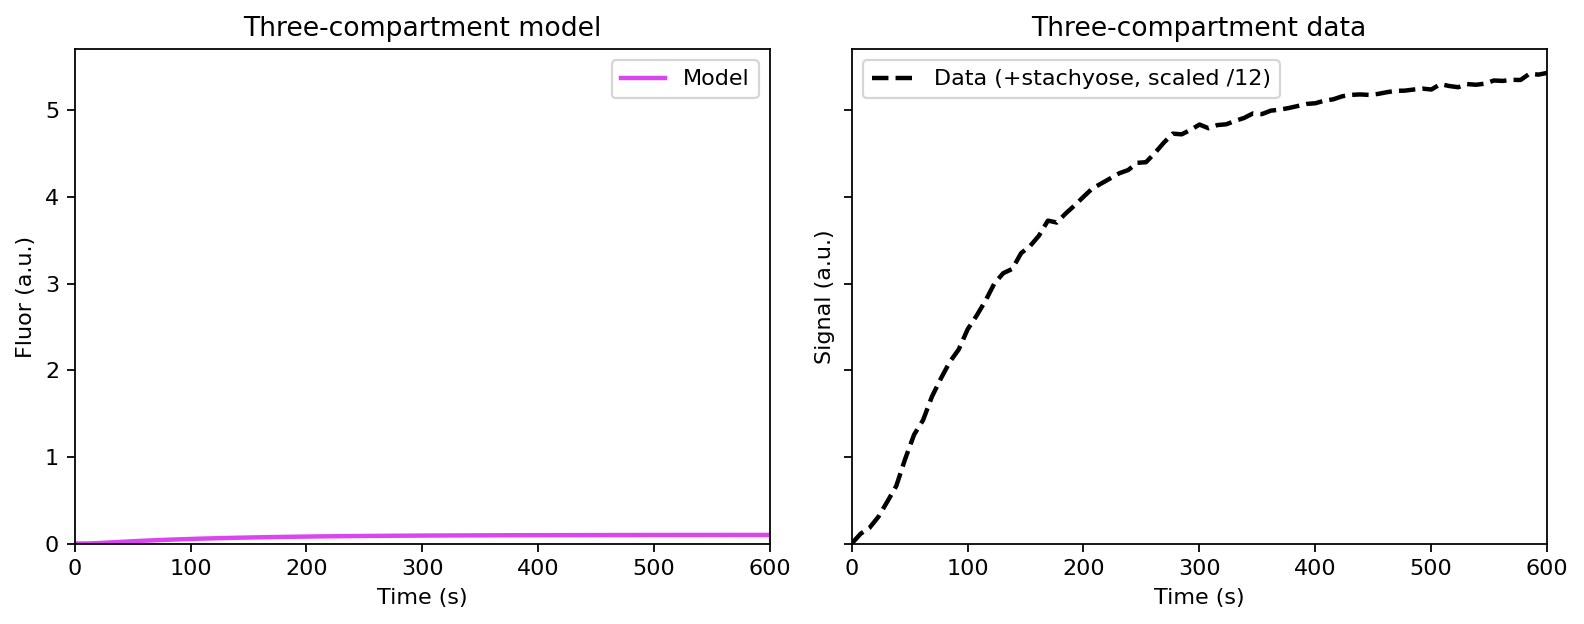

In [53]:
comp3_time_col = find_col(Results_comp3, "time", exact="time")
comp3_res_col = find_col(Results_comp3, "resorufin", exact="resorufin_Internal_1")

model_y = Results_comp3[comp3_time_col * 0 + comp3_res_col] if False else Results_comp3[comp3_res_col]
data_y = df_comp3["data_scaled"]

shared_ymax = max(model_y.max(), data_y.max()) * 1.05

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].plot(
    Results_comp3[comp3_time_col],
    model_y,
    color=COLOR_MODEL,
    linewidth=2,
    label="Model"
)

axes[0].set_title("Three-compartment model")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Fluor (a.u.)")
axes[0].set_xlim(0, 600)
axes[0].set_ylim(0, shared_ymax)
axes[0].legend()

axes[1].plot(
    df_comp3["timepoints"],
    data_y,
    color=COLOR_DATA,
    linestyle="--",
    linewidth=2,
    label="Data (+stachyose, scaled /12)"
)

axes[1].set_title("Three-compartment data")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Signal (a.u.)")   
axes[1].set_xlim(0, 600)
axes[1].set_ylim(0, shared_ymax)
axes[1].legend()

fig.tight_layout()
save_fig(fig, "fig_1E_three_compartment_model_vs_data.png")
plt.show()

Saved: cleaned_notebook_figures/fig_1F_three_compartment_sanity_checks.png


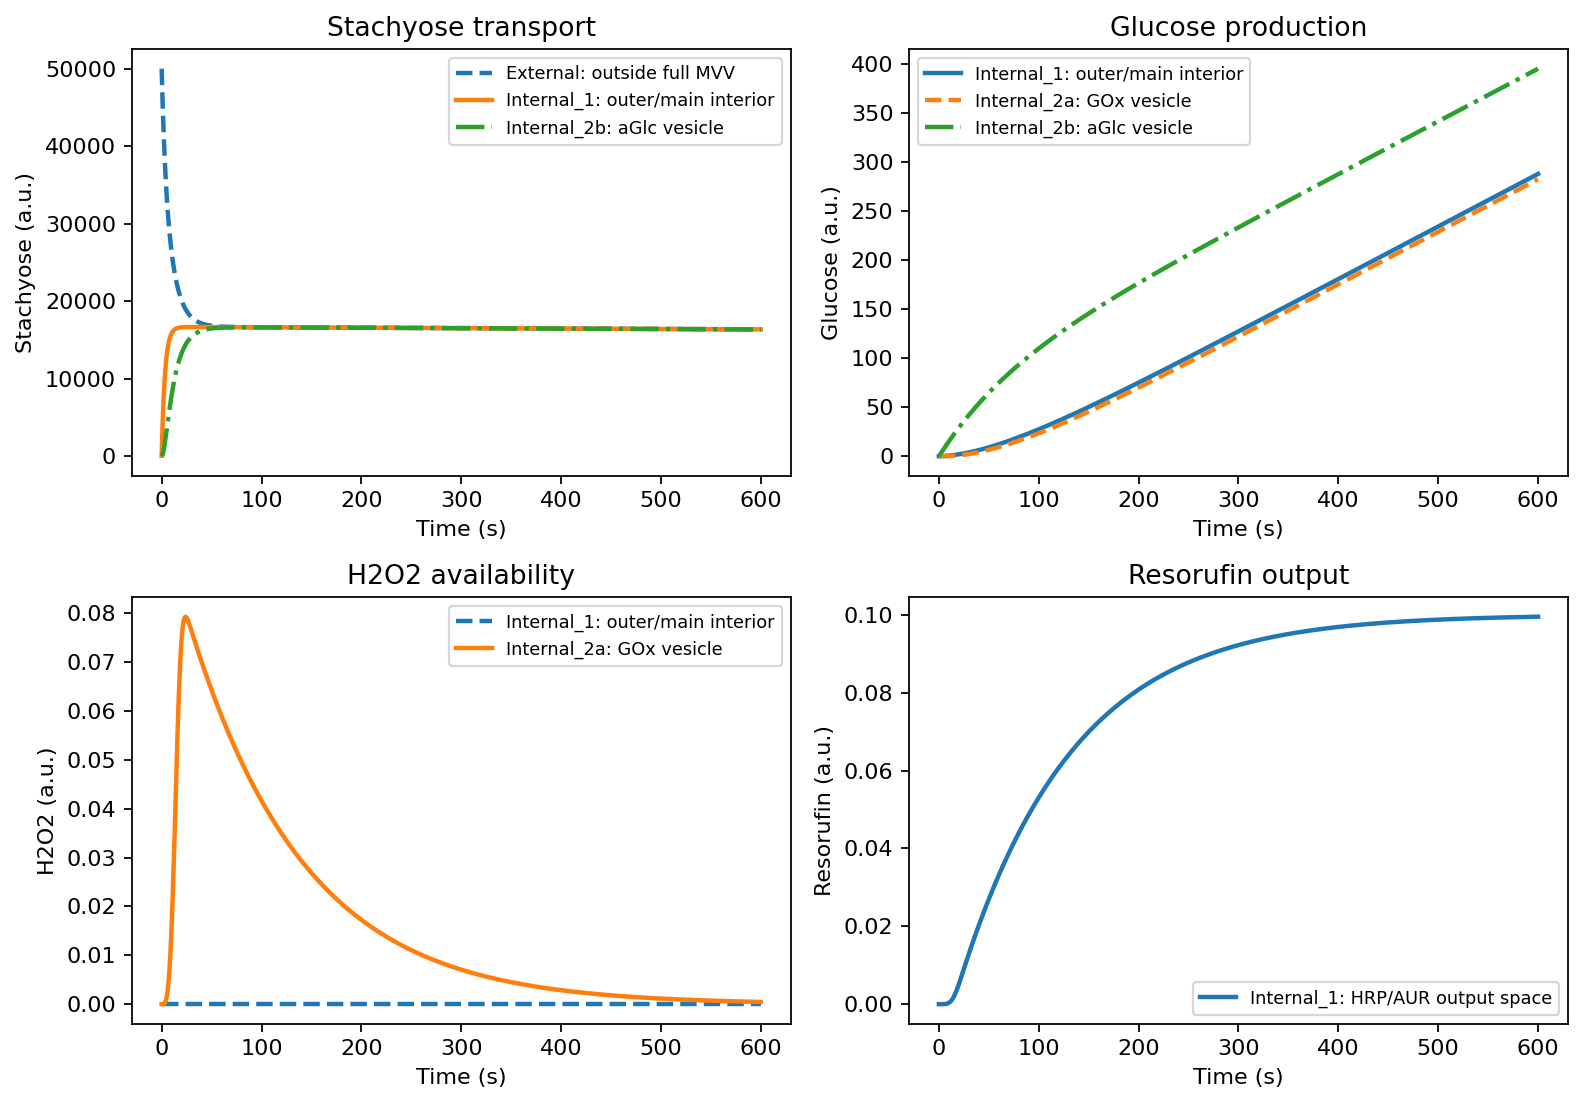

In [61]:
# note:
# Three-compartment sanity checks with all key species plotted to verify expected transport and reactions.

if "Results_comp3_sanity" in globals():
    results3_sanity = Results_comp3_sanity
else:
    results3_sanity = Results_comp3

comp3_time_col = find_col(results3_sanity, "time", exact="time")

stach_ext_col = find_col(results3_sanity, "stachyose_External", exact="stachyose_External")
stach_1_col   = find_col(results3_sanity, "stachyose_Internal_1", exact="stachyose_Internal_1")
stach_2b_col  = find_col(results3_sanity, "stachyose_Internal_2b", exact="stachyose_Internal_2b")

glucose_1_col  = find_col(results3_sanity, "glucose_Internal_1", exact="glucose_Internal_1")
glucose_2a_col = find_col(results3_sanity, "glucose_Internal_2a", exact="glucose_Internal_2a")
glucose_2b_col = find_col(results3_sanity, "glucose_Internal_2b", exact="glucose_Internal_2b")

h2o2_1_col  = find_col(results3_sanity, "H2O2_Internal_1", exact="H2O2_Internal_1")
h2o2_2a_col = find_col(results3_sanity, "H2O2_Internal_2a", exact="H2O2_Internal_2a")

res_col = find_col(results3_sanity, "resorufin", exact="resorufin_Internal_1")

t = results3_sanity[comp3_time_col]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# 1. Stachyose transport
axes[0, 0].plot(
    t,
    results3_sanity[stach_ext_col],
    linestyle="--",
    linewidth=2,
    label="External: outside full MVV"
)

axes[0, 0].plot(
    t,
    results3_sanity[stach_1_col],
    linewidth=2,
    label="Internal_1: outer/main interior"
)

axes[0, 0].plot(
    t,
    results3_sanity[stach_2b_col],
    linestyle="-.",
    linewidth=2,
    label="Internal_2b: aGlc vesicle"
)

axes[0, 0].set_title("Stachyose transport")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Stachyose (a.u.)")
axes[0, 0].legend(fontsize=8)

# 2. Glucose production
axes[0, 1].plot(
    t,
    results3_sanity[glucose_1_col],
    linewidth=2,
    label="Internal_1: outer/main interior"
)

axes[0, 1].plot(
    t,
    results3_sanity[glucose_2a_col],
    linestyle="--",
    linewidth=2,
    label="Internal_2a: GOx vesicle"
)

axes[0, 1].plot(
    t,
    results3_sanity[glucose_2b_col],
    linestyle="-.",
    linewidth=2,
    label="Internal_2b: aGlc vesicle"
)

axes[0, 1].set_title("Glucose production")
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].set_ylabel("Glucose (a.u.)")
axes[0, 1].legend(fontsize=8)

# 3. H2O2 availability
axes[1, 0].plot(
    t,
    results3_sanity[h2o2_1_col],
    linestyle="--",
    linewidth=2,
    label="Internal_1: outer/main interior"
)

axes[1, 0].plot(
    t,
    results3_sanity[h2o2_2a_col],
    linewidth=2,
    label="Internal_2a: GOx vesicle"
)

axes[1, 0].set_title("H2O2 availability")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("H2O2 (a.u.)")
axes[1, 0].legend(fontsize=8)

# 4. Resorufin output
axes[1, 1].plot(
    t,
    results3_sanity[res_col],
    linewidth=2,
    label="Internal_1: HRP/AUR output space"
)

axes[1, 1].set_title("Resorufin output")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("Resorufin (a.u.)")
axes[1, 1].legend(fontsize=8)

fig.tight_layout()
save_fig(fig, "fig_1F_three_compartment_sanity_checks.png")
plt.show()

**Three-compartment sanity-check interpretation.**  
Stachyose decreases in the external space and appears in the outer/main vesicle interior and in the aGlc inner vesicle, showing that inward transport is occurring. Glucose is produced in the aGlc inner vesicle and is also present in the shared outer/main vesicle interior and in the GOx inner vesicle, which is consistent with intermediate production and downstream availability across compartments. H2O2 is generated mainly in the GOx inner vesicle, while much less appears in the outer/main vesicle interior where HRP and AUR produce resorufin. Resorufin in the outer/main vesicle interior still increases over time, confirming that the model reaches the final fluorescence-producing step. Together, these sanity checks suggest that the three-compartment cascade is functioning mechanistically and capturing meaningful transport and intermediate formation, even though the model-vs-data comparison shows that the simulated fluorescence magnitude is still much smaller than the experimental signal.